In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np 
import polars as pl
import sys
import os
import ctypes

# Set path (only needed for Windows users to resolve incompatibility from rpy2)
conda_env_path = r"C:\Users\liang\anaconda3\envs\hdc"
r_home = os.path.join(conda_env_path, "lib", "R")
r_bin = os.path.join(r_home, "bin", "x64")
library_bin = os.path.join(conda_env_path, "Library", "bin")

# Set variables
os.environ["R_HOME"] = r_home
os.environ["PATH"] = r_bin + ";" + library_bin + ";" + os.environ["PATH"]

# Load DLLs manually
try:
    if os.path.exists(r_bin):
        os.add_dll_directory(r_bin)
    if os.path.exists(library_bin):
        os.add_dll_directory(library_bin)
    print("DLLs loaded successfully.")
except AttributeError:
    pass

# --- BYPASS RPY2 AUTO-DETECTION ---
# rpy2 crashes trying to find flags we already loaded. We will silence it.
import rpy2.situation

def mock_get_r_flags(r_home, *args):
    # Create a dummy object that returns an empty list of libraries
    class MockFlags:
        L = [] 
    return (MockFlags(),)

# Overwrite the function causing the crash
rpy2.situation.get_r_flags = mock_get_r_flags
print("Patched rpy2 to skip auto-detection.")

sys.path.append('../')
from data.neuroloader import RLoader 

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.


DLLs loaded successfully.
Patched rpy2 to skip auto-detection.


In [2]:
def preprocess(data,training_window,bin_size,n_states = 5):
    ''' 
        Preprocess the odor data into training
    '''
    odor_data = {}
    rat_name = ['Barat','Buchanan','Mitt','Stella','Superchris']

    for irat in range(5):
        bin_spk =(    
            data[irat]# only use one rat for now 
            # compute relative t
            .with_columns(
                        (1 + 1e3*(pl.col('TimeBin') - pl.col('TimeBin').min().over(['trial_id','y'])))
                        .round()
                        .cast(pl.Int32)
                        .alias('relative_t')
                        )
            # e.g. extract 250-500 after poke in
            .filter(
                (pl.col('relative_t') >= training_window[0]) & 
                (pl.col('relative_t') <  training_window[1]) )
            # bin them
            .with_columns(
                (pl.col('relative_t')//bin_size).alias('bin_id')
            ) 
            # compute the total firing spk
            .group_by('y','seq_id','trial_id','bin_id')
            .agg(
                pl.col("^.*U.*$").sum() 
            )
            .with_columns(
                        (pl.col('y')-1).alias('y'),
                        (pl.col('bin_id')-pl.min('bin_id')).alias('bin_id'))
            .filter(pl.col('y')<n_states)
            .sort('y','seq_id','trial_id','bin_id')) 

        split_trial = [spk[:,4:].to_numpy() for spk in bin_spk.partition_by('trial_id')]
        y = np.concatenate([spk["y"].unique().to_numpy() for spk in bin_spk.partition_by("trial_id")])
        tri = np.concatenate([spk["trial_id"].unique().to_numpy() for spk in bin_spk.partition_by("trial_id")])
        
        split_trial_np = np.array(split_trial) #(trials, T, neurons)
          
        odor_data[irat] = {
            'rat_name': rat_name[irat],
            'binned_spk': split_trial_np,
            'y':y, 
            'trial_id':tri,
            'spk_df':bin_spk}
        
    return odor_data


def preprocess_run(train_data,bin_size):
    ''' 
        Preprocess the running data into test
    '''
    run_data = {}
    rat_name = ['Barat','Buchanan','Mitt','Stella','Superchris']

    for irat in range(5):
        bin_spk = (
                train_data[irat]
                .with_columns(
                        (1e3*(pl.col('TimeBin') - pl.col('TimeBin').min().over(['trial_id','y'])))
                        .round()
                        .cast(pl.Int32)
                        .alias('relative_t')
                        )
                .filter(pl.col('y')==6,pl.col('relative_t')<200) 
                .with_columns(
                            (pl.col('relative_t')//bin_size).alias('bin_id')
                        ) 
                # compute the total firing spk
                .group_by('y','seq_id','trial_id','bin_id')
                .agg(
                    pl.col("^.*U.*$").sum() 
                )
                .sort('y','seq_id','bin_id') 
            )

        
        split_trial = [spk[:,4:].to_numpy() for spk in bin_spk.partition_by('trial_id')]
        y = np.concatenate([spk["y"].unique().to_numpy() for spk in bin_spk.partition_by("trial_id")])
        tri = np.concatenate([spk["trial_id"].unique().to_numpy() for spk in bin_spk.partition_by("trial_id")])
        
        split_trial_np = np.array(split_trial) #(trials, T, neurons)
 
        run_data[irat] = {
            'rat_name': rat_name[irat],
            'binned_spk': split_trial_np,
            'y':y, 
            'trial_id':tri,
            'spk_df':bin_spk}
    return run_data

## Load data
1. Take 200-600 ms and bin each 25 ms, a total of 16 bins.
2. Aggregate each bin by average firing rate.

In [3]:
#---------- load class---------------------------
# NOTE change it to your path!
raw_loader = RLoader(path='../data/OST_r/')

#---------- load raw data---------------------------
# NOTE num_class choice: 4(A-D), 5(A-E), 6(A-E + Running)
train_data = raw_loader.load_train_data()

total rat number for train is:5


In [4]:
#---------- preprocess data---------------------------
# extract the training window, and bin the spike
training_window = (200,600)
my_bin_size = 25

odor_data = preprocess(
    train_data,
    training_window=training_window,
    bin_size=my_bin_size,
    n_states = 4
    )

In [ ]:

def check_dist(X,y):

    # Flatten time (treat the whole trial as one long vector for this check)
    X_flat = X.reshape(X.shape[0], -1) 

    # Calculate distances
    from sklearn.metrics.pairwise import euclidean_distances
    dists = euclidean_distances(X_flat)

    # Mask for Same vs Diff
    same_mask = y[:, None] == y[None, :]
    np.fill_diagonal(same_mask, False)
    diff_mask = ~same_mask

    avg_dist_same = dists[same_mask].mean()
    avg_dist_diff = dists[diff_mask].mean()

    print(f"Raw Euclidean Dist | Same: {avg_dist_same:.2f} | Diff: {avg_dist_diff:.2f}")

In [ ]:
 

rat_name = ['Barat','Buchanan','Mitt','Stella','Superchris']
for i, rat in enumerate(rat_name):
    print(f"Rat name: {rat}")
    X = odor_data[i]['binned_spk']
    y = odor_data[i]['y']
    print(f"Number of Trials: {X.shape[0]}, number of bins: {X.shape[1]}, number of neurons: {X.shape[2]}")
    
    check_dist(X,y)

Rat name: Barat
Number of Trials: 133, number of bins: 16, number of neurons: 92
Raw Euclidean Dist | Same: 13.60 | Diff: 13.66
Rat name: Buchanan
Number of Trials: 174, number of bins: 16, number of neurons: 79
Raw Euclidean Dist | Same: 12.07 | Diff: 12.50
Rat name: Mitt
Number of Trials: 207, number of bins: 16, number of neurons: 104
Raw Euclidean Dist | Same: 11.44 | Diff: 11.60
Rat name: Stella
Number of Trials: 152, number of bins: 16, number of neurons: 49
Raw Euclidean Dist | Same: 12.36 | Diff: 12.62
Rat name: Superchris
Number of Trials: 164, number of bins: 16, number of neurons: 46
Raw Euclidean Dist | Same: 11.66 | Diff: 12.23


In [28]:
from pathlib import Path
import pickle

out_path = Path("../data/rat") / f"odor_prep_{training_window}_{my_bin_size}.pickle"
out_path.parent.mkdir(parents=True, exist_ok=True)

with out_path.open("wb") as f:
    pickle.dump(odor_data, f, protocol=pickle.HIGHEST_PROTOCOL)

In [6]:
run_data = preprocess_run(
    train_data,bin_size=my_bin_size)

In [7]:
rat_name = ['Barat','Buchanan','Mitt','Stella','Superchris']
for i, rat in enumerate(rat_name):
    print(f"Rat name: {rat}")
    X = run_data[i]['binned_spk']
    y = run_data[i]['y']
    print(f"Number of Trials: {X.shape[0]}, number of bins: {X.shape[1]}, number of neurons: {X.shape[2]}")

Rat name: Barat
Number of Trials: 21, number of bins: 8, number of neurons: 92
Rat name: Buchanan
Number of Trials: 28, number of bins: 8, number of neurons: 79
Rat name: Mitt
Number of Trials: 23, number of bins: 8, number of neurons: 104
Rat name: Stella
Number of Trials: 24, number of bins: 8, number of neurons: 49
Rat name: Superchris
Number of Trials: 26, number of bins: 8, number of neurons: 46


In [34]:
run_window = (0,200)

out_path = Path("../data/rat") / f"run_prep_{run_window}_{my_bin_size}.pickle"
out_path.parent.mkdir(parents=True, exist_ok=True)

with out_path.open("wb") as f:
    pickle.dump(run_data, f, protocol=pickle.HIGHEST_PROTOCOL)

## Binned data visualization
Visualize the binned odor data the run data.

In [8]:
rat_name = ['Barat','Buchanan','Mitt','Stella','SuperChris']

avg_spk_lst = []
for irat in range(5):
    spk_by_trial = pl.concat([odor_data[irat]['spk_df'],run_data[irat]['spk_df'] ],how='vertical')
    print(spk_by_trial.shape) # (trials*bins, neurons+ids)
    avg_spk = (
        spk_by_trial
        .group_by('y','bin_id')
        .agg(
            pl.col("^.*U.*$").mean()* 1e3 /my_bin_size # convert to Hz:spk/s
        )
        .sort('y','bin_id') 
    )
    mapping = {c: f"{rat_name[irat]}_{c}" for c in avg_spk.select(pl.col(r"^.*U.*$")).columns}
    avg_spk = avg_spk.rename(mapping) 
    if irat>=1:
        avg_spk_lst.append(avg_spk[:,2:])
    else:
        avg_spk_lst.append(avg_spk)
avg_spk_all = pl.concat(avg_spk_lst, how = 'horizontal')

(2296, 96)
(3008, 83)
(3496, 108)
(2624, 53)
(2832, 50)


In [9]:
import matplotlib.pyplot as plt 

states_label = ['A','B','C','D','RUN'] 

spk_train = avg_spk_all[:, 2:].to_numpy().transpose()

# Extract odor IDs (y) from col 1
y_labels = avg_spk_all[:, 0].to_numpy()
unique_y = np.sort(np.unique(y_labels))

thr = 0
y2label = {y: states_label[i] for i, y in enumerate(unique_y)}

K = len(unique_y)

# width = number of time bins for each y
width_ratios = [spk_train[:, y_labels == y].shape[1] for y in unique_y]

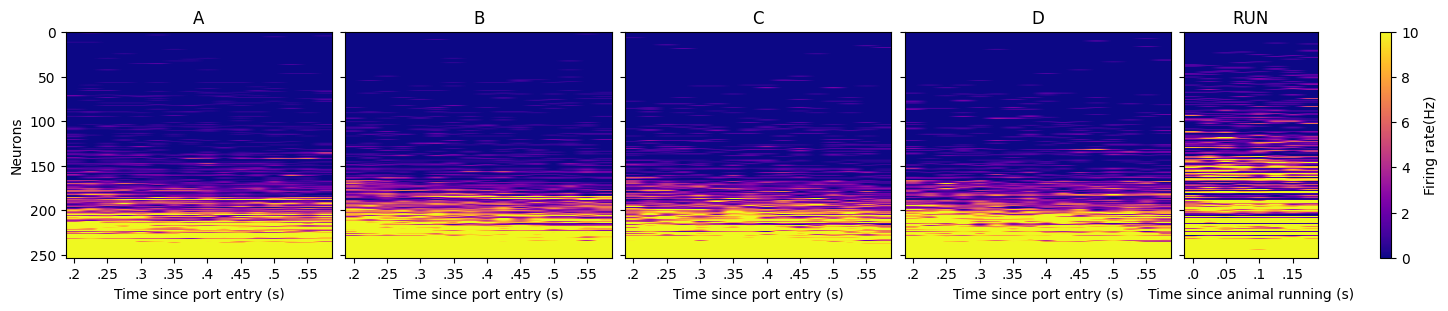

In [10]:
# show the different template
fig, axes = plt.subplots(
    1, K,
    figsize=(0.2*sum(width_ratios), 3),  # scales nicely with total bins
    sharey=True,
    constrained_layout=True,
    gridspec_kw={"width_ratios": width_ratios}
)
 
cmap = plt.get_cmap("plasma")

im = None

# # sort based on total firing rate
fired_sum = spk_train.sum(axis=1)

mask = fired_sum != 0
spk_nz = spk_train[mask, :]
fired_sum_nz = fired_sum[mask]

sumorder = np.argsort(fired_sum_nz) 

# remove the neurons that have no activity across states
spk_train_ordered = spk_train[mask,:][sumorder,:]

for ax, y in zip(axes, unique_y):
    group = spk_train_ordered[:, y_labels == y]  # (neurons, time bins)

    im = ax.imshow(
        group, aspect="auto", cmap=cmap, vmin=0, vmax=10
        )
    ax.set_title(f"{y2label.get(y, y)}")
    ax.set_xlabel("Time since port entry (s)")

    # ticks in "bin units" (adjust if each bin != 1 ms)
    if group.shape[1] >= 16:
        ax.set_xticks(np.arange(0, 16, 2))
        # ax.set_xticks([0.2, 0.25, 0.3, 0.5, 0.6])
        ax.set_xticklabels([".2", ".25", ".3", '.35','.4','.45',".5",'.55'])
    else: 
        ax.set_xticks(np.arange(0, group.shape[1], 2))
        ax.set_xticklabels([".0", ".05", ".1", ".15"])
        ax.set_xlabel('Time since animal running (s)')
        

axes[0].set_ylabel("Neurons")
fig.colorbar(im, ax=axes, label="Firing rate(Hz)")
plt.show()

## Encoded data visualization
Visualize the encoded hvs with TSNE

In [11]:
from hdc_encoder.neuro import *
from NeuroHDC.fn import *
import polars as pl  
import seaborn as sns
from pathlib import Path
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

In [ ]:
BETA = 0.3
DIM = 15_000
RANDOM_STATE = 0 
TRAINING_WINDOW = (200, 600)
RUNNING_WINDOW = (0, 200)
BIN_SIZE = 25
SLICING_WINDOW = 200
STEP_BINS = 2 

path_id = Path("../data/rat") / f"odor_prep_{TRAINING_WINDOW}_{BIN_SIZE}.pickle"
path_ood = Path("../data/rat") / f"run_prep_{RUNNING_WINDOW}_{BIN_SIZE}.pickle"

encoded_hvs = []
encoded_class = []

for irat in range(5):
    splits= prep_loader_slicing(
            irat=irat, 
            split_ratio=(0.5, 0.4, 0.1), 
            in_path=path_id,
            step_bins=STEP_BINS,
            slicing_window=SLICING_WINDOW,
            bin_size=BIN_SIZE,
            seed=RANDOM_STATE
        )
    
    X_train, y_train = splits.train.X, splits.train.y
    X_cal, y_cal = splits.cal.X, splits.cal.y
    X_test, y_test = splits.test.X, splits.test.y
    
    # Load OOD Data
    with path_ood.open("rb") as f:
        run_data = pickle.load(f)
    X_ood = run_data[irat]['binned_spk']
    
    # Encoder Setup
    n, nT, p = X_train.shape 
    rff = RFF(n_feature=p, dimension=DIM, seed=RANDOM_STATE)
    W = rff.gen_basis(cov=np.eye(p)) 
    TB = rff.gen_time_base()
    
    # Encode
    enc_train = rff.encode_all(W, X_train, TB, beta=BETA)
    enc_cal   = rff.encode_all(W, X_cal, TB, beta=BETA)
    enc_test  = rff.encode_all(W, X_test, TB, beta=BETA)
    enc_ood   = rff.encode_all(W, X_ood, TB, beta=BETA)

    encoded_hvs.append(
        np.vstack([enc_train, enc_cal, enc_test, enc_ood])
    )
    encoded_class.append(
        np.hstack([y_train, y_cal, y_test, -np.ones(len(enc_ood))])
    )

Original Shape: (133, 16, 92)
Applying sliding window of 200 ms (8 bins)
Augmented Shape: (665, 8, 92)
Original Shape: (174, 16, 79)
Applying sliding window of 200 ms (8 bins)
Augmented Shape: (870, 8, 79)


In [ ]:
cdict = {0: 'skyblue', 1: 'sienna', 2: 'forestgreen', 3: 'rebeccapurple', -1: 'grey'}
ldict = {0: "A", 1: "B", 2: "C", 3: "D", -1: "RUN"}
rat_name = ['Barat','Buchanan','Mitt','Stella','Superchris']

sns.set_context("paper", font_scale=1.5)
sns.set_style("ticks")

for i in [4]:
    print(f'Visualizing hvs for {rat_name[i]}.')
    X = encoded_hvs[i].real
    y = encoded_class[i]

    X_embedded = TSNE(
        n_components=2,
        learning_rate='auto',
        early_exaggeration=12,
        metric='euclidean',
        init='pca',
        perplexity=100,
        n_jobs=-1,
        random_state=0
    ).fit_transform(X)

    # 2. Adjust figsize for a more compact, square look
    fig, ax = plt.subplots(figsize=(6, 5)) 
    
    for g in np.unique(y): 
        mask = (y == g)   
        ax.scatter(
            X_embedded[mask, 0],
            X_embedded[mask, 1],
            c=cdict.get(g, 'black'),
            s=35,               # Increased size to make the plot feel "fuller"
            alpha=0.8,          # Slight transparency for overlapping points
            label=ldict.get(g),
            edgecolors='white', 
            linewidth=0.6
        )
        
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    
    # Set aspect to equal so the plot isn't stretched, reducing "empty" space
    #ax.set_aspect('equal', adjustable='datalim')
    
    ax.legend(
        loc='upper center', 
        bbox_to_anchor=(0.5, -0.18), 
        ncol=len(np.unique(y)), 
        frameon=False,
        markerscale=1.2,
        handletextpad=0.1,  # Shrink space between icon and text
        columnspacing=1.0   # Shrink space between legend items
    )

    sns.despine()
    
    plt.tight_layout()
    plt.savefig(f"../results/plots/{rat_name[i]}_tsne.svg", dpi=300, bbox_inches='tight')
    plt.show()